# Meta-Learner Comparison: S / T / X / R Learners

This notebook compares the four online meta-learners on a heterogeneous CATE stream.

| Learner | Key idea | CATE available? |
|---|---|---|
| S-Learner | Single model with treatment as feature | Yes |
| T-Learner | Separate models per arm | Yes |
| X-Learner | Three-stage with imputed effects | Yes |
| R-Learner | Robinson residual transformation | Yes |

**Data:** `HeterogeneousCausalStream` with `heterogeneity='nonlinear'`.

In [1]:
from river.linear_model import LinearRegression

from onlinecml.datasets import HeterogeneousCausalStream
from onlinecml.metalearners import OnlineSLearner, OnlineTLearner, OnlineXLearner, OnlineRLearner

## 1. Fit all four learners

In [2]:
N = 1000
TRUE_ATE = 2.0

s_learner = OnlineSLearner(model=LinearRegression())
t_learner = OnlineTLearner(
    treated_model=LinearRegression(),
    control_model=LinearRegression(),
)
x_learner = OnlineXLearner(
    mu1_model=LinearRegression(),
    mu0_model=LinearRegression(),
    tau1_model=LinearRegression(),
    tau0_model=LinearRegression(),
)
r_learner = OnlineRLearner(cate_model=LinearRegression())

stream = HeterogeneousCausalStream(n=N, true_ate=TRUE_ATE, heterogeneity="nonlinear", seed=42)

for x, w, y, tau in stream:
    s_learner.learn_one(x, w, y)
    t_learner.learn_one(x, w, y)
    x_learner.learn_one(x, w, y)
    r_learner.learn_one(x, w, y)

print(f"Population ATE  : {stream.population_ate():.3f}")
print(f"S-Learner ATE   : {s_learner.predict_ate():.3f}")
print(f"T-Learner ATE   : {t_learner.predict_ate():.3f}")
print(f"X-Learner ATE   : {x_learner.predict_ate():.3f}")
print(f"R-Learner ATE   : {r_learner.predict_ate():.3f}")

Population ATE  : 2.000
S-Learner ATE   : 1.601
T-Learner ATE   : 1.859
X-Learner ATE   : 1.683
R-Learner ATE   : 1.600


## 2. Individual CATE predictions

In [3]:
# A test unit
x_test = {"x0": 1.0, "x1": 0.0, "x2": -0.5}

print("CATE for x_test:")
print(f"  S-Learner : {s_learner.predict_one(x_test):.3f}")
print(f"  T-Learner : {t_learner.predict_one(x_test):.3f}")
print(f"  X-Learner : {x_learner.predict_one(x_test):.3f}")
print(f"  R-Learner : {r_learner.predict_one(x_test):.3f}")

CATE for x_test:
  S-Learner : 1.815
  T-Learner : 3.089
  X-Learner : 3.093
  R-Learner : 3.078


## 3. ATE convergence comparison

Saved to /tmp/metalearner_comparison.png


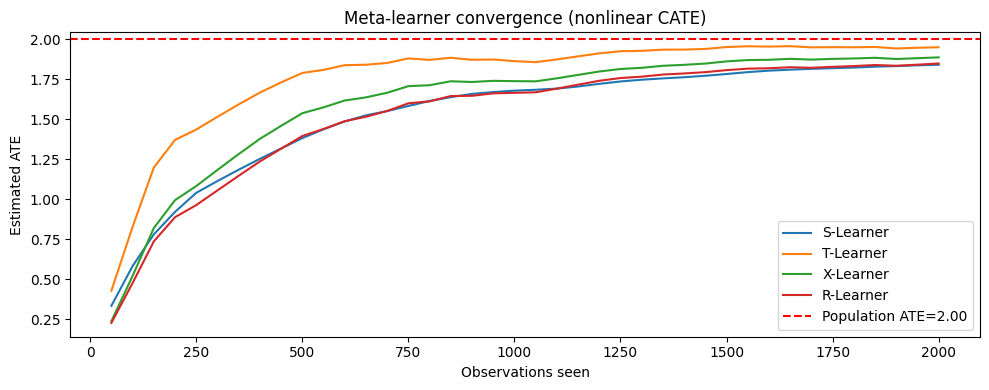

In [4]:
import matplotlib
import matplotlib.pyplot as plt

learners = {
    "S-Learner": OnlineSLearner(model=LinearRegression()),
    "T-Learner": OnlineTLearner(treated_model=LinearRegression(), control_model=LinearRegression()),
    "X-Learner": OnlineXLearner(
        mu1_model=LinearRegression(), mu0_model=LinearRegression(),
        tau1_model=LinearRegression(), tau0_model=LinearRegression(),
    ),
    "R-Learner": OnlineRLearner(cate_model=LinearRegression()),
}

LOG_EVERY = 50
history = {k: [] for k in learners}
steps = []

stream2 = HeterogeneousCausalStream(n=2000, true_ate=2.0, heterogeneity="nonlinear", seed=7)
pop_ate = stream2.population_ate()

for i, (x, w, y, tau) in enumerate(stream2):
    for m in learners.values():
        m.learn_one(x, w, y)
    if (i + 1) % LOG_EVERY == 0:
        steps.append(i + 1)
        for name, m in learners.items():
            history[name].append(m.predict_ate())

fig, ax = plt.subplots(figsize=(10, 4))
for name, ates in history.items():
    ax.plot(steps, ates, label=name)
ax.axhline(pop_ate, color="red", linestyle="--", label=f"Population ATE={pop_ate:.2f}")
ax.set_xlabel("Observations seen")
ax.set_ylabel("Estimated ATE")
ax.set_title("Meta-learner convergence (nonlinear CATE)")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/metalearner_comparison.png", dpi=100)
print("Saved to /tmp/metalearner_comparison.png")

## 4. Heterogeneity recovery

Compare true CATE vs predicted CATE on a held-out grid.

In [5]:
import math

# Nonlinear DGP: true CATE = true_ate + x0 + sin(x1)*0.5
grid = [{"x0": x0, "x1": 0.0, "x2": 0.0} for x0 in [-2, -1, 0, 1, 2]]

print(f"{'x0':>4} | {'True CATE':>10} | {'S':>8} | {'T':>8} | {'X':>8} | {'R':>8}")
print("-" * 60)
for pt in grid:
    x0 = pt["x0"]
    true_cate = 2.0 + x0 + math.sin(0.0) * 0.5
    preds = {name: m.predict_one(pt) for name, m in learners.items()}
    print(
        f"{x0:>4.0f} | {true_cate:>10.3f} | "
        f"{preds['S-Learner']:>8.3f} | {preds['T-Learner']:>8.3f} | "
        f"{preds['X-Learner']:>8.3f} | {preds['R-Learner']:>8.3f}"
    )

  x0 |  True CATE |        S |        T |        X |        R
------------------------------------------------------------
  -2 |      0.000 |    2.006 |    0.252 |    0.190 |    0.274
  -1 |      1.000 |    2.006 |    1.150 |    1.086 |    1.151
   0 |      2.000 |    2.006 |    2.048 |    1.983 |    2.027
   1 |      3.000 |    2.006 |    2.946 |    2.880 |    2.904
   2 |      4.000 |    2.006 |    3.844 |    3.776 |    3.781
